- Missing values uitleggen
- Missing values verklaren
- Placeholder values uitzoeken
- Placeholder values verklaren
- Missing values invullen?
- Echt per feature uitleggen en verklaren niet zomaar iets doen zonder onderbouwing.
- Feature Time series analysis
- Target variable price change (Time series)

# GitIgnore

Created a filtered dataset reduced from 28 to 15 columns.

Since the datasets are to big to push to github and don't belong in github. Added datasets .csv, .parquet, .xslx files to gitignore.

In [1]:
import io, math
from scipy.io import arff
from sklearn.metrics import max_error
from sklearn.metrics import mean_squared_error

import sklearn
import pandas as pd
import seaborn
import shap

import numpy as np

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms, models

from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix

c:\Users\Ayoub\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#data column selection only exectued once to select columns
if False:
    df = pd.read_csv("../Dataset/us-derived-shareprices-daily.csv", sep=";")
    df.columns = df.columns.str.strip()

    print(df.columns.tolist())

Make sure we select the right columns from the initial dataset. Although additional features were available in the dataset, they were excluded because they were not identified as relevant indicators during the stakeholder interview and literature review. Since explainability and domain relevance were prioritised over purely predictive performance, only stakeholder-supported variables were used for model development.


In [3]:
# Data filtering step (executed once to create smaller working dataset)
if False:

    # columns we want to use
    cols = [
        "Ticker", 
        "Date", 
        "Adj. Close", 
        "Volume", 
        "Market-Cap",
        "Price to Earnings Ratio (ttm)",
        "Price to Sales Ratio (ttm)",
        "Price to Book Value",
        "Price to Free Cash Flow (ttm)",
        "EV/EBITDA", 
        "EV/Sales",
        "Book to Market Value",
        "Operating Income/EV",
        "Altman Z Score",
        "Dividend Yield"
    ]

    # load only selected columns
    df = pd.read_csv(
        "us-derived-shareprices-daily/us-derived-shareprices-daily.csv",
        usecols=cols,
        sep=";"
    )

    # convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # filter between 2022 and end of 2025
    df = df[df["Date"].between("2022-01-01", "2025-12-31")]

    # save filtered dataset
    df.to_csv("filtered_shares_ratios_3years.csv", index=False)

    print("created filtered dataset")


df = pd.read_csv("../filtered_shares_ratios_3years.csv")
df.describe()


,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


In this describe even if it is in scientific notation. We can already cleary see in the min and max values huge discrepencies. We have 0 values, as well as huge values seen by the amount of zeros added to some max values.

This suggest that the dataset contains extreme outliers, as well as unusable values for training a model.

In [4]:
df.sample(5)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
85259,ADM,2022-02-18,67.88,4011328,4.274415e+10,15.82719,0.50295,1.88325,7.27079,12.94313,0.60564,0.53100,0.05797,3.21613,0.01945
3026522,MSFT,2023-05-10,305.10,30078044,2.327022e+12,33.76156,11.22507,11.96932,27.86448,22.99107,10.93884,0.08355,0.03734,9.45860,0.00832
4861671,WBS,2023-05-17,33.61,2070018,6.328419e+09,6.50207,2.12907,0.67839,4.30623,13.15794,6.07861,1.47408,0.07066,NaN,0.05289
1652520,EYE,2025-07-17,25.09,1831710,1.983456e+09,-75.96148,1.06699,2.36180,45.47823,21.10010,1.40899,0.42341,0.01232,2.01302,NaN
1505944,ELTP,2023-10-18,0.10,544581,1.013915e+08,NaN,NaN,3.36435,NaN,NaN,NaN,0.29723,NaN,NaN,NaN


Here is a random sample taken from the data which confirms our earlier idea. We can see alot of missing or unusable values as well as very fluctuating values. Since this is the baseline model we won't dive into fixing this.

In the baseline model we established there were recurring weird values so we're gonna take a deeper look into this. It would be interesting to get an idea of the values we have inside our dataset

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print(numeric_cols)

for col in numeric_cols:
    print("\n", col)
    print(
        df[col]
        .value_counts()
        .head(20)
    )

['Adj. Close', 'Volume', 'Market-Cap', 'Price to Earnings Ratio (ttm)', 'Price to Sales Ratio (ttm)', 'Price to Book Value', 'Price to Free Cash Flow (ttm)', 'EV/EBITDA', 'EV/Sales', 'Book to Market Value', 'Operating Income/EV', 'Altman Z Score', 'Dividend Yield']

 Adj. Close
Adj. Close
0.00     55304
0.01     18181
0.02     11107
0.03      8376
0.04      8108
0.05      6907
1.00      6559
0.10      5614
0.06      5591
10.00     5484
2.00      5304
5.00      5282
0.07      5081
3.00      4539
0.17      4177
2.50      4144
1.50      4025
0.20      3975
0.15      3968
4.00      3945
Name: count, dtype: int64

 Volume
Volume
0       195157
1         9345
100       7303
2         5367
3         3446
200       3343
5         2927
4         2683
10        2666
1000      2202
6         2037
500       1949
300       1874
20        1573
7         1566
50        1483
8         1448
400       1399
12        1181
11        1180
Name: count, dtype: int64

 Market-Cap
Market-Cap
0.000000e+00    56

Initially, the dataset appeared to contain complete observations. However, frequency analysis revealed repeated occurrences of the values 99999.99999 and -99999.99999 across multiple financial ratios. Also values of 0 which in itself is no problem, but they are heavily present in ratios were normally 0 values wouldn't be expected like P/E. These values were interpreted as placeholders rather than valid financial observations and were therefore converted to missing values before assessing dataset completeness. This ensured that completeness calculations reflected actual data availability rather than the presence of placeholder values.

The order in which we execute these operations is very important. If we would first delete all NaN and check for data completness per company and select those companies. And only after that remove placeholders. We would again be placed in a situation were we are uncertain about the state of our dataset.

In [6]:
placeholder_values = [
    99999.99999,
    -99999.99999
]

results = []

for col in numeric_cols:

    mask = df[col].isin(placeholder_values)

    results.append({
        "Feature": col,
        "Placeholder Count": mask.sum(),
        "Placeholder %": mask.mean() * 100,
        "Contribution %": df.loc[mask, col].abs().sum()/df[col].abs().sum()* 100
    })

placeholder_summary_df = pd.DataFrame(results)

placeholder_summary_df

,Feature,Placeholder Count,Placeholder %,Contribution %
0,Adj. Close,0,0.000000,0.000000
1,Volume,0,0.000000,0.000000
2,Market-Cap,0,0.000000,0.000000
3,Price to Earnings Ratio (ttm),1870,0.036831,27.656419
4,Price to Sales Ratio (ttm),3111,0.061274,49.576483
5,Price to Book Value,948,0.018672,31.750647
6,Price to Free Cash Flow (ttm),896,0.017647,24.377727
7,EV/EBITDA,343,0.006756,16.009938
8,EV/Sales,2412,0.047506,52.437234
9,Book to Market Value,220,0.004333,30.342019


In [24]:
clean_df = df.replace(
    placeholder_values,
    np.nan
)

stats_before = df[numeric_cols].describe().T
stats_after = clean_df[numeric_cols].describe().T

stats_comparison = pd.DataFrame({
    "Mean Before": stats_before["mean"],
    "Mean After": stats_after["mean"],
    "Std Before": stats_before["std"],
    "Std After": stats_after["std"],
    "Min Before": stats_before["min"],
    "Min After": stats_after["min"],
    "Max Before": stats_before["max"],
    "Max After": stats_after["max"]
})

stats_comparison

,Mean Before,Mean After,Std Before,Std After,Min Before,Min After,Max Before,Max After
Adj. Close,2.508054e+04,2.508054e+04,1.419652e+06,1.419652e+06,0.00000,0.00000,1.000000e+08,1.000000e+08
Volume,1.703947e+06,1.703947e+06,1.106200e+07,1.106200e+07,0.00000,0.00000,5.497020e+09,5.497020e+09
Market-Cap,4.219712e+12,4.219712e+12,4.197879e+14,4.197879e+14,0.00000,0.00000,5.698460e+16,5.698460e+16
Price to Earnings Ratio (ttm),-1.730331e+01,-1.067875e+01,2.812195e+03,1.656535e+03,-99999.99999,-99943.14578,1.000000e+05,8.890226e+04
Price to Sales Ratio (ttm),1.370486e+02,8.236509e+01,3.520416e+03,1.704842e+03,-99999.99999,-99894.01431,1.000000e+05,9.990815e+04
Price to Book Value,1.063825e+01,1.652057e+01,1.900016e+03,1.126365e+03,-99999.99999,-99617.75696,1.000000e+05,9.993253e+04
Price to Free Cash Flow (ttm),-2.022930e+01,-1.811944e+00,2.239674e+03,1.329887e+03,-99999.99999,-99709.71750,1.000000e+05,6.407077e+04
EV/EBITDA,1.040932e+00,-5.467772e-01,1.370573e+03,9.004355e+02,-99999.99999,-99820.23291,1.000000e+05,9.725865e+04
EV/Sales,7.648980e+01,4.378210e+01,3.095022e+03,1.431530e+03,-99999.99999,-99972.64000,1.000000e+05,9.997906e+04
Book to Market Value,1.096683e+01,6.687289e+00,8.267660e+02,3.602127e+02,-99999.99999,-50000.00000,1.000000e+05,5.000000e+04


Even after cleaning the dataset with the first supsected placeholders, there still seem to be other unexplainable large values and other suspected placeholders like -500.000/500.000, we will for now first look how much these outliers contribute to the dataset and if they are worth further cleaning.

In [28]:
extreme_threshold = 10000

results = []

for col in numeric_cols:

    mask = clean_df[col].abs() > extreme_threshold

    results.append({
        "Feature": col,
        "Extreme Count": mask.sum(),
        "Extreme %": mask.mean() * 100,
        "Contribution %":
            clean_df.loc[mask, col].abs().sum()
            /
            clean_df[col].abs().sum()
            * 100
    })

extreme_summary_df = pd.DataFrame(results)

extreme_summary_df

,Feature,Extreme Count,Extreme %,Contribution %
0,Adj. Close,13286,0.261678,99.757521
1,Volume,4241534,83.540431,99.976988
2,Market-Cap,4785368,94.251680,100.000000
3,Price to Earnings Ratio (ttm),8815,0.173619,46.897626
4,Price to Sales Ratio (ttm),5878,0.115772,61.037989
5,Price to Book Value,3641,0.071712,55.060859
6,Price to Free Cash Flow (ttm),4215,0.083018,38.884778
7,EV/EBITDA,2439,0.048038,35.106905
8,EV/Sales,3793,0.074706,58.573566
9,Book to Market Value,897,0.017667,34.113021


In [30]:
for col in numeric_cols:

    print("\n", col)

    print(
        clean_df[col].quantile([
            0.001,
            0.005,
            0.01,
            0.05,
            0.95,
            0.99,
            0.995,
            0.999
        ])
    )


 Adj. Close
0.001         0.00000
0.005         0.00000
0.010         0.00000
0.050         0.64000
0.950       204.92000
0.990       707.54340
0.995      2560.51150
0.999    432561.16636
Name: Adj. Close, dtype: float64

 Volume
0.001    0.000000e+00
0.005    0.000000e+00
0.010    0.000000e+00
0.050    5.000000e+01
0.950    6.014906e+06
0.990    2.323762e+07
0.995    3.921792e+07
0.999    1.029897e+08
Name: Volume, dtype: float64

 Market-Cap
0.001    0.000000e+00
0.005    0.000000e+00
0.010    0.000000e+00
0.050    8.795970e+06
0.950    5.184526e+10
0.990    2.137250e+11
0.995    3.716949e+11
0.999    1.989423e+12
Name: Market-Cap, dtype: float64

 Price to Earnings Ratio (ttm)
0.001   -12807.329363
0.005    -1935.422130
0.010     -841.206510
0.050      -77.311560
0.950       77.184145
0.990      507.473594
0.995     1324.750972
0.999    11184.951954
Name: Price to Earnings Ratio (ttm), dtype: float64

 Price to Sales Ratio (ttm)
0.001      -42.649428
0.005        0.000000
0.010    

In [25]:
# Check extreme values after placeholder cleaning

extreme_threshold = 10000

extreme_summary = []

for col in numeric_cols:
    mask = clean_df[col].abs() > extreme_threshold

    extreme_summary.append({
        "Feature": col,
        "Extreme Count": mask.sum(),
        "Extreme %": mask.mean() * 100,
        "Min": clean_df[col].min(),
        "Max": clean_df[col].max()
    })

extreme_summary_df = pd.DataFrame(extreme_summary)

extreme_summary_df

,Feature,Extreme Count,Extreme %,Min,Max
0,Adj. Close,13286,0.261678,0.00000,1.000000e+08
1,Volume,4241534,83.540431,0.00000,5.497020e+09
2,Market-Cap,4785368,94.251680,0.00000,5.698460e+16
3,Price to Earnings Ratio (ttm),8815,0.173619,-99943.14578,8.890226e+04
4,Price to Sales Ratio (ttm),5878,0.115772,-99894.01431,9.990815e+04
5,Price to Book Value,3641,0.071712,-99617.75696,9.993253e+04
6,Price to Free Cash Flow (ttm),4215,0.083018,-99709.71750,6.407077e+04
7,EV/EBITDA,2439,0.048038,-99820.23291,9.725865e+04
8,EV/Sales,3793,0.074706,-99972.64000,9.997906e+04
9,Book to Market Value,897,0.017667,-50000.00000,5.000000e+04


In [26]:
for col in numeric_cols:
    print("\n", col)
    print(
        clean_df[col]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )


 Adj. Close
3060279    99999999.99
3060278    99999999.99
3060287    99999999.99
3060286    99999999.99
3060285    99999999.99
3060284    99999999.99
3061085    99999999.99
3061084    99999999.99
3061069    99999999.99
3061068    99999999.99
Name: Adj. Close, dtype: float64

 Volume
2103725    5497020301
2103757    4460612173
2103474    3104130958
2103504    2169183103
2103726    2146534000
781909     2130552459
3535232    2094305794
2103760    2053360825
3370563    1958424543
2103756    1941702824
Name: Volume, dtype: int64

 Market-Cap
544254    5.698460e+16
544257    5.662279e+16
544253    5.632129e+16
544255    5.601978e+16
544256    5.595948e+16
544258    5.583888e+16
544264    5.553737e+16
544259    5.547707e+16
544265    5.535647e+16
544252    5.529617e+16
Name: Market-Cap, dtype: float64

 Price to Earnings Ratio (ttm)
1831906    99943.14578
1831902    99943.14578
1831899    99943.14578
1831903    99943.14578
1831904    99943.14578
1831905    99943.14578
1831849    99943.14578

In [27]:
# Inspect extreme values for one feature

col = "Price to Earnings Ratio (ttm)"

clean_df[
    clean_df[col].abs() > 10000
][["Ticker", "Date", col]].head(20)

,Ticker,Date,Price to Earnings Ratio (ttm)
4891,AAGH,2022-01-03,-21574.80712
4892,AAGH,2022-01-04,-24894.00821
4893,AAGH,2022-01-05,-24894.00821
4894,AAGH,2022-01-06,-26553.60876
4895,AAGH,2022-01-07,-23234.40766
4896,AAGH,2022-01-10,-23234.40766
4897,AAGH,2022-01-11,-21574.80712
4898,AAGH,2022-01-12,-21574.80712
4899,AAGH,2022-01-13,-19915.20657
4900,AAGH,2022-01-14,-19915.20657


In [ ]:
# 6. Replace original dataframe after evidence is shown

df = clean_df.copy()

Although the placeholder values represented less than 0.1% of observations in every feature, they contributed between 16% and 69% of the total feature magnitude. This indicates that a very small number of observations disproportionately influenced the feature distributions. Combined with the repeated occurrence of the exact values ±99999.99999 across multiple financial ratios, these observations were classified as placeholder values and converted to missing values before further preprocessing.

In [9]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Dividend Yield                   67.768266
Price to Free Cash Flow (ttm)    45.675441
Altman Z Score                   43.687228
EV/Sales                         36.955497
EV/EBITDA                        36.731280
Price to Sales Ratio (ttm)       35.512346
Operating Income/EV              29.532719
Price to Earnings Ratio (ttm)    28.703782
Book to Market Value             21.767450
Price to Book Value              20.257826
Market-Cap                        4.537480
Ticker                            0.017194
Volume                            0.000000
Date                              0.000000
Adj. Close                        0.000000
dtype: float64

In [10]:
pe_placeholder_pct = (
    df["Price to Earnings Ratio (ttm)"]
    .isin([99999.99999, -99999.99999])
    .mean()
)

print(pe_placeholder_pct * 100)

0.03683115750480134


Here we see for each feature the percentage amount of missing values. It's clear that for most values this a way to high number to use in this state for training a model.

# Data cleaning and Pre processing notebook

Since this is the baseline model we don't dive to deep into our research how we got to these solutions. However coming to these conclusions took extensive hypothesis and experimentation to confirm the hypothesis which is covered in the Data cleaning and pre processing notebook.

# Preprocessing

Since the dataset is full of outliers, huge differences in values, and missing values or unusable values, as well as text values. This imposes challenging but interesting work for making the dataset suitable for a machine learning model. Since this is still the baseline model, we will keep preprocessing for now as minimally as possible to be able to use the dataset.

In [11]:
ratio_cols = [
    "Price to Earnings Ratio (ttm)",
    "Price to Sales Ratio (ttm)",
    "Price to Book Value",
    "Price to Free Cash Flow (ttm)",
    "EV/EBITDA",
    "EV/Sales",
    "Book to Market Value",
    "Operating Income/EV",
    "Altman Z Score",
    "Dividend Yield"
]

ticker_quality = (
    df.groupby("Ticker")[ratio_cols]
      .apply(lambda x: x.notna().mean().mean())
      .sort_values(ascending=False)
)

print(ticker_quality)

Ticker
ZEUS    1.0
ZBH     1.0
ABBV    1.0
AAPL    1.0
YUM     1.0
       ... 
KRNT    0.0
EE      0.0
JSPR    0.0
STG     0.0
ZWS     0.0
Length: 5793, dtype: float64


In [12]:
print("Companies with >= 90% completeness:",
      (ticker_quality >= 0.90).sum())

print("Companies with >= 95% completeness:",
      (ticker_quality >= 0.95).sum())

print("Companies with 100% completeness:",
      (ticker_quality == 1.00).sum())

print("Total companies:", df["Ticker"].nunique())

Companies with >= 90% completeness: 2062
Companies with >= 95% completeness: 844
Companies with 100% completeness: 681
Total companies: 5793


In [13]:
complete_tickers = ticker_quality[ticker_quality == 1.0].index.tolist()

print(complete_tickers)
print("Number of complete companies:", len(complete_tickers))

['ZEUS', 'ZBH', 'ABBV', 'AAPL', 'YUM', 'XYL', 'XRX', 'XRAY', 'XPER', 'XOM', 'XLNX', 'XHR', 'WYNN', 'WWW', 'WWE', 'WWD', 'WU', 'ACA', 'ABT', 'WTW', 'WTS', 'WST', 'WSM', 'WRK', 'WNC', 'WMT', 'WMS', 'WMG', 'WMB', 'WM', 'WLFC', 'WIRE', 'WING', 'WINA', 'WHR', 'WHG', 'ACC', 'WHD', 'WGO', 'WEYS', 'WERN', 'WEN', 'WELL', 'WEC', 'WDFC', 'WCN', 'WCC', 'WBA', 'WAB', 'ACN', 'VTRS', 'VST', 'VSEC', 'VRTS', 'VRT', 'VRSK', 'VRS', 'VNT', 'VNO', 'VMI', 'VMC', 'VICI', 'VCTR', 'VATE', 'V', 'UTZ', 'UTMD', 'USLM', 'USG', 'UPS', 'UNP', 'UNH', 'UNF', 'ULH', 'UI', 'UHAL', 'UGI', 'UFPI', 'TXRH', 'TXN', 'TTEK', 'TTEC', 'TTC', 'TT', 'ADP', 'ADI', 'ADES', 'TSN', 'TSCO', 'TRU', 'TRTN', 'TRP', 'TROX', 'TROW', 'TRGP', 'TRCY', 'TR', 'AEE', 'AE', 'TOL', 'TNL', 'TNC', 'TMO', 'TM', 'TKR', 'TJX', 'TILE', 'THO', 'TGT', 'TGLS', 'TER', 'TEL', 'TECH', 'TDG', 'TAP', 'TACO', 'SYY', 'SYK', 'SXT', 'SXC', 'SWM', 'SWKS', 'SWK', 'SWI', 'SWCH', 'SWBI', 'SVC', 'SUP', 'STZ', 'STX', 'AGFS', 'AGCO', 'STRA', 'STOR', 'STLD', 'STE', 'SSTK', 

In [14]:
print(ticker_quality.sample(20))

Ticker
YGYI    0.945455
FORA    0.687737
ENTG    1.000000
MMP     0.900000
SNPO    0.900000
VCEL    0.539781
NOMD    0.300000
ENFN    0.928692
JEF     0.970090
CADE    0.000000
IEA     0.900000
XYL     1.000000
RDN     0.625324
VAL     0.183649
IMVT    0.600000
DBI     0.782054
CIGI    0.000000
JMSB    0.665404
AMT     0.453340
ENZN    0.378564
dtype: float64


Here you can see how much difference there is in the dataset in completness of the data per company

In [15]:
good_tickers = ticker_quality[ticker_quality >= 0.90].index

df_good = df[df["Ticker"].isin(good_tickers)]

print("Companies:", df_good["Ticker"].nunique())
print("Rows:", len(df_good))

Companies: 2062
Rows: 1796191


In [16]:
(df_good.isnull().sum() / len(df_good) * 100).sort_values(ascending=False)

Dividend Yield                   46.957478
Altman Z Score                    5.948477
Price to Free Cash Flow (ttm)     2.030519
EV/EBITDA                         0.617807
EV/Sales                          0.290893
Operating Income/EV               0.286439
Book to Market Value              0.269403
Price to Book Value               0.238282
Price to Earnings Ratio (ttm)     0.069703
Price to Sales Ratio (ttm)        0.062521
Market-Cap                        0.004287
Volume                            0.000000
Ticker                            0.000000
Date                              0.000000
Adj. Close                        0.000000
dtype: float64

In [17]:
company_df = df_good.groupby("Ticker").last()
df_good = df_good.drop(columns=["Date", "Ticker","Dividend Yield"])


corr = company_df.corr(numeric_only=True)["Adj. Close"]

print(corr.sort_values())

Volume                          -0.006352
Price to Sales Ratio (ttm)      -0.001399
EV/Sales                        -0.001273
Price to Book Value             -0.000902
Book to Market Value            -0.000397
Operating Income/EV             -0.000391
Price to Earnings Ratio (ttm)   -0.000382
Altman Z Score                   0.000553
EV/EBITDA                        0.000744
Price to Free Cash Flow (ttm)    0.001685
Dividend Yield                   0.035076
Market-Cap                       0.117756
Adj. Close                       1.000000
Name: Adj. Close, dtype: float64


In [18]:
#Check if all columns are the right datatypes
print(df_good.dtypes)

Adj. Close                       float64
Volume                             int64
Market-Cap                       float64
Price to Earnings Ratio (ttm)    float64
Price to Sales Ratio (ttm)       float64
Price to Book Value              float64
Price to Free Cash Flow (ttm)    float64
EV/EBITDA                        float64
EV/Sales                         float64
Book to Market Value             float64
Operating Income/EV              float64
Altman Z Score                   float64
dtype: object


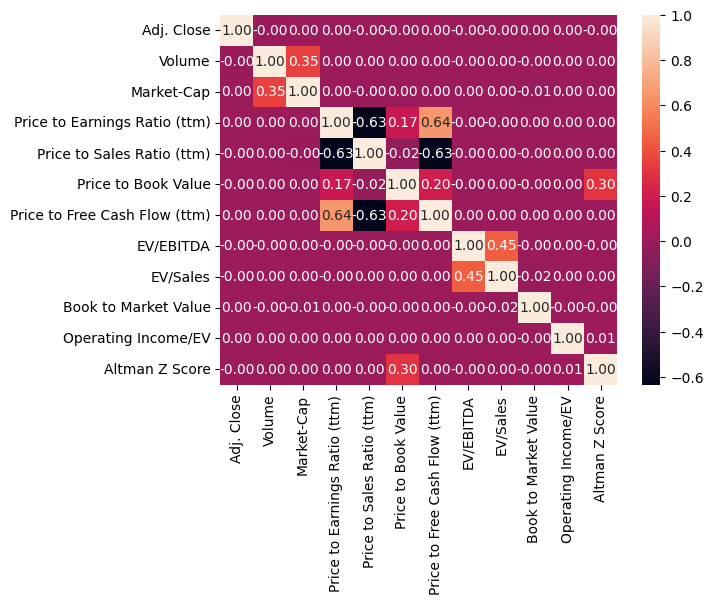

In [19]:
correlations = df_good.corr()
plot = seaborn.heatmap(correlations, cbar=True, annot=True, fmt=".2f")

# Correlation Matrix with Target variable
In this correlation matrix it shows that the target variable has very weak correlations with the other features. In general all of the features are very weak to none correlation. 

However this correlation matrix does not support or domain analysis. This dataset with its features was selected based on the stakeholders input how they analyze businesses and what they look at for stock prices. Since the stakeholder runs a succesfull investment firm and these practices they've applied for many years.

We make the hypothesis that this correlation matrix doesn't accurately represent the features correlations. And there might be an issue in the dataset.

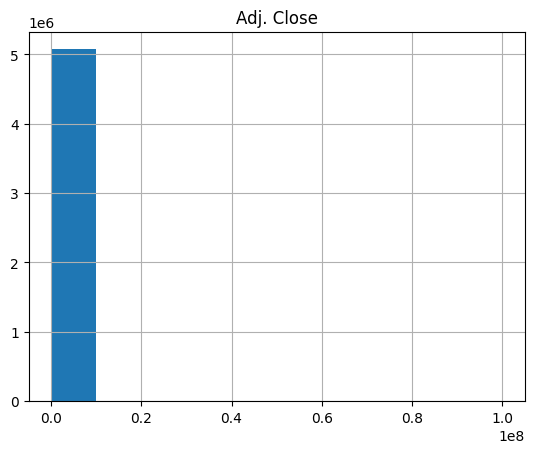

In [20]:
plot = df.hist(column="Adj. Close")

<Axes: >

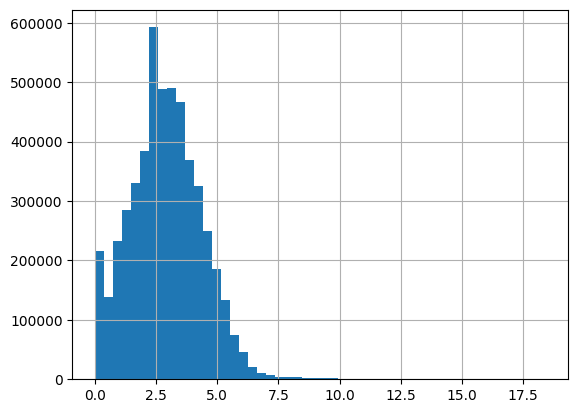

In [21]:
df["log_adj_close"] = np.log1p(df["Adj. Close"])
df["log_adj_close"].hist(bins=50)

Since the current dataset contains so many missing or unreliable values like -100.000 / 100.000. Or is just heavily influenced by the huge differences between prices. Producing any visually usable graph without logging is impossible. So we log the data to make the target variable visually understandable.

We can see the data is lightly skewed but mostly normally distributed.

In [22]:
for col in df_good.select_dtypes(include=["number"]).columns:
    print(f"\n=== {col} ===")
    print(df_good[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))

    print("\nTop 10 values:")
    print(df_good[col].sort_values(ascending=False).head(10))

    print("\nBottom 10 values:")
    print(df_good[col].sort_values().head(10))


=== Adj. Close ===
count    1.796191e+06
mean     1.200725e+04
std      7.959814e+05
min      0.000000e+00
1%       7.400000e-01
5%       2.540000e+00
50%      3.173000e+01
95%      2.809350e+02
99%      6.124410e+02
99.9%    9.424680e+03
max      8.043840e+07
Name: Adj. Close, dtype: float64

Top 10 values:
4897143    80438400.0
4897203    80136000.0
4897141    79228800.0
4897142    78926400.0
4897140    78624000.0
4897144    78022224.0
4897162    77871024.0
4897155    77716800.0
4897159    77716800.0
4897158    76809600.0
Name: Adj. Close, dtype: float64

Bottom 10 values:
4247574    0.0
4247573    0.0
4247572    0.0
4247603    0.0
4247602    0.0
4247601    0.0
4247600    0.0
4247610    0.0
4247773    0.0
4247627    0.0
Name: Adj. Close, dtype: float64

=== Volume ===
count    1.796191e+06
mean     2.445955e+06
std      1.326609e+07
min      0.000000e+00
1%       1.600000e+02
5%       1.090400e+04
50%      5.509920e+05
95%      8.443886e+06
99%      3.042888e+07
99.9%    1.346886e+0

Shows that the entire dataset each feature contains extreme outlier and placeholder values for NaN values making the dataset unusable in it's current state.

# Workaround


You can also try and work the other way around instead of arbitraly cleaning up ur dataset. Since this is the baseline model I'll keep it short but in the, preprocessing notebook you can see my attempts at cleaning the dataset, and how I pivoted to looking for right data instead of wrong data. 

You can just look in the dataset for companies that contain all financial ratios and data. and then just use those companies for the modeling.

In [23]:
df_trim = df_good.copy()

df_trim.drop(
    columns=["log_adj_close"],
    errors="ignore"
).copy()

numeric_cols = df_trim.select_dtypes(include=["number"]).columns

for col in numeric_cols:

    lower = df_trim[col].quantile(0.01)
    upper = df_trim[col].quantile(0.99)

    df_trim = df_trim[
        (df_trim[col] >= lower) &
        (df_trim[col] <= upper)
    ]

print("Original shape:", df_good.shape)
print("Trimmed shape:", df_trim.shape)

KeyboardInterrupt: 

Here we arbitrarly eliminate bottom and top 0,5% of the dataset to remove extreme values

In [ ]:
corr_original = (
    df_good
    .corr(numeric_only=True)["Adj. Close"]
    .sort_values()
)

corr_trimmed = (
    df_trim
    .corr(numeric_only=True)["Adj. Close"]
    .sort_values()
)

print("ORIGINAL")
print(corr_original)

print("\nTRIMMED")
print(corr_trimmed)

In [ ]:
print(
    corr_original.abs().sort_values(ascending=False)
)

In [ ]:
print(
    corr_trimmed.abs().sort_values(ascending=False)
)

In [ ]:
for col in df_trim.columns:
    print(f"\n{'='*60}")
    print(col)
    print('='*60)

    print(
        df_trim[col].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        )
    )

In [ ]:
import matplotlib.pyplot as plt

for col in df_good.columns:

    plt.figure(figsize=(8, 4))

    df_good[col].hist(
        bins=100
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()


In [ ]:

for col in df_trim.columns:

    plt.figure(figsize=(8, 4))

    df_trim[col].hist(
        bins=100
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

Above you can see difference in the graphs distributions from the dataframe before and after the cleaning and selection. There are a couple of valuable observations, of weird behaviour.

1. We can see that the range of values dramatically decreases

2. We can see alot of features are heavily skewed which is normal and inline with what we expected.

3. Ideally we would like to see even curves in the graphs indicating a spreaded distribitution. However in some features graphs we still see some unexplainable fluctuations that require further investigation. Like drops around the 0 value.

4. This is also strange since for some graphs we wouldn't expect 0 values but they still contain them and some of them quite alot.